# Week 8: Decision Trees (ID3)

## Student Practice Notebook

**Name:** M.Sukanya
**Roll Number:** AP24110011837
**Date:** 9/10/2026

## Learning Objectives

After completing this lab, you will be able to:

- Compute entropy and information gain, by hand and in code
- Build an ID3 decision tree by hand on a small table (the exam-style problem)
- Fit and read a `DecisionTreeClassifier`
- Explain how tree depth controls overfitting (same idea as K in Week 7 and degree in Week 6)
- Explain how a tree differs from KNN: it asks questions about *features*, it does not measure *distance*

### Why this week matters
KNN (Week 7) classified by "who is closest?". A decision tree classifies by asking a chain of yes/no questions about features, and you can read the questions. That readability is why trees are used in credit, healthcare and fraud work, and why every ensemble in Unit V is built from them.


## Part 0 — Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score

%matplotlib inline
np.random.seed(1)


## Part 1 — Entropy and Information Gain

**Entropy** measures how mixed a set of labels is: $H = -\sum p_i \log_2 p_i$. A pure set (all one class) has entropy 0. A 50/50 two-class set has entropy 1.

**Information gain** of splitting on an attribute = entropy before − weighted average entropy after. ID3 always picks the attribute with the highest gain.

### 1.1 Demo: entropy in code


In [2]:
def entropy(counts):
    counts = np.array(counts, dtype=float)
    p = counts[counts > 0] / counts.sum()
    return float(-np.sum(p * np.log2(p))) + 0.0

print('Pure set      [10, 0]:', entropy([10, 0]))
print('50/50 set     [5, 5] :', entropy([5, 5]))
print('Skewed set    [9, 1] :', entropy([9, 1]))


Pure set      [10, 0]: 0.0
50/50 set     [5, 5] : 1.0
Skewed set    [9, 1] : 0.4689955935892812


**Predict, then think:** which has higher entropy, a 70/30 split or a 90/10 split? Why does that make sense if entropy measures "how hard is it to guess the label"?

*Your answer:* 70/30 split has high entropy than 90/10 split because When one class has more samples than the other, it becomes easier to guess the label, so entropy is low.


### Student Practice — entropy of a split

A parent node has 8 Yes and 6 No. A candidate split sends 6 samples to the left child (6 Yes, 0 No) and 8 samples to the right child (2 Yes, 6 No). Compute the entropy of the parent and the information gain of the split.


In [3]:
# Write your answer here
import numpy as np

def entropy(counts):
    counts = np.array(counts, dtype=float)
    p = counts[counts > 0] / counts.sum()
    return -np.sum(p * np.log2(p))
parent_entropy = entropy([8, 6])
left_entropy = entropy([6, 0])
right_entropy = entropy([2, 6])
weighted_entropy = (6/14) * left_entropy + (8/14) * right_entropy
information_gain = parent_entropy - weighted_entropy
print("Parent Entropy:", round(parent_entropy, 4))
print("Left Child Entropy:", round(left_entropy, 4))
print("Right Child Entropy:", round(right_entropy, 4))
print("Weighted Child Entropy:", round(weighted_entropy, 4))
print("Information Gain:", round(information_gain, 4))

Parent Entropy: 0.9852
Left Child Entropy: -0.0
Right Child Entropy: 0.8113
Weighted Child Entropy: 0.4636
Information Gain: 0.5216


## Part 2 — ID3 by Hand (the exam-style problem)

Classic 14-day "play tennis" table. Target: `Play`.


In [4]:
tennis = pd.DataFrame({
    'Outlook':     ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast','Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool','Cool','Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity':    ['High','High','High','High','Normal','Normal','Normal','High','Normal','Normal','Normal','High','Normal','High'],
    'Wind':        ['Weak','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'Play':        ['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No'],
})
tennis


,Outlook,Temperature,Humidity,Wind,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [7]:
def info_gain(df, attribute, target='Play'):
    total = entropy(df[target].value_counts())
    weighted = 0
    for value, subset in df.groupby(attribute):
        weighted += len(subset) / len(df) * entropy(subset[target].value_counts())
    return total - weighted

print('Root entropy:', round(entropy(tennis['Play'].value_counts()), 4))
print('Gain(Wind)  :', round(info_gain(tennis, 'Wind'), 4))


Root entropy: 0.9403
Gain(Wind)  : 0.0481


### Student Practice — find the root

1. Compute the information gain for `Outlook`, `Temperature` and `Humidity` using `info_gain`.
2. Which attribute does ID3 pick as the root?
3. For the root's branch that is **not** pure, which attribute would you split on next? (Filter `tennis` to that branch and recompute gains.)


In [6]:
# Write your answer here
attributes = ['Outlook', 'Temperature', 'Humidity']
print("Root Entropy:", round(entropy(tennis['Play'].value_counts()), 4))
for attribute in attributes:
    print(f"Gain({attribute}):", round(info_gain(tennis, attribute), 4))
root = max(attributes, key=lambda a: info_gain(tennis, a))
print("\nRoot Attribute:", root)
remaining = [a for a in ['Outlook', 'Temperature', 'Humidity', 'Wind']
             if a != root]
for value, subset in tennis.groupby(root):
    print(f"\n{root} = {value}")
    if subset['Play'].nunique() == 1:
        print("Pure branch -> Play =", subset['Play'].iloc[0])
    else:
        print("Information Gain for remaining attributes:")

        for attribute in remaining:
            print(f"Gain({attribute}):",
                  round(info_gain(subset, attribute), 4))

        best_next = max(remaining,
                        key=lambda a: info_gain(subset, a))
        print("Next split:", best_next)

Root Entropy: 0.9403
Gain(Outlook): 0.2467
Gain(Temperature): 0.0292
Gain(Humidity): 0.1518

Root Attribute: Outlook

Outlook = Overcast
Pure branch -> Play = Yes

Outlook = Rain
Information Gain for remaining attributes:
Gain(Temperature): 0.02
Gain(Humidity): 0.02
Gain(Wind): 0.971
Next split: Wind

Outlook = Sunny
Information Gain for remaining attributes:
Gain(Temperature): 0.571
Gain(Humidity): 0.971
Gain(Wind): 0.02
Next split: Humidity


**Reflection:** `Overcast` became a leaf immediately. In your own words, why does a pure branch need no further splitting?

*Your answer:* A pure branch contains samples from only one class. Since all the samples in the Overcast branch have Play = Yes, the entropy is 0. So, no further splitting is needed.


## Part 3 — `DecisionTreeClassifier` on Iris

Same Iris split as Week 7, so you can compare directly. Note: **trees do not need feature scaling**, because they compare a feature to a threshold, not distances between points. That is a real difference from KNN.


Test accuracy: 0.9555555555555556


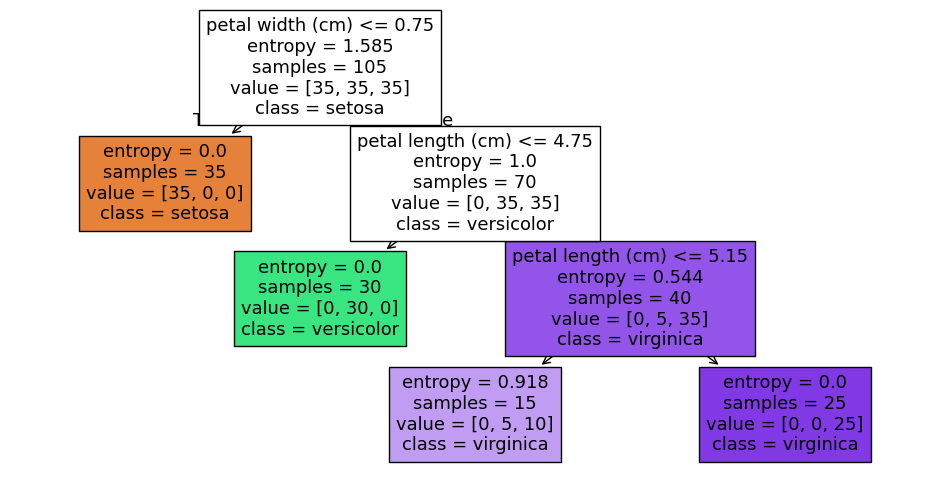

In [8]:
iris = load_iris(as_frame=True)
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

tree = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=1)
tree.fit(X_train, y_train)
print('Test accuracy:', accuracy_score(y_test, tree.predict(X_test)))

plt.figure(figsize=(12, 6))
plot_tree(tree, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()


### Student Practice — depth sweep

Sweep `max_depth` from 1 to 15. Record train and test accuracy for each, plot both, and report the depth with the best test accuracy.


Depth | Train Accuracy | Test Accuracy
    1 |         0.6667 |        0.6667
    2 |         0.9524 |        0.9556
    3 |         0.9524 |        0.9556
    4 |         0.9524 |        0.9333
    5 |         0.9714 |        0.9778
    6 |         0.9810 |        0.9778
    7 |         0.9810 |        0.9778
    8 |         0.9905 |        0.9778
    9 |         1.0000 |        0.9778
   10 |         1.0000 |        0.9778
   11 |         1.0000 |        0.9778
   12 |         1.0000 |        0.9778
   13 |         1.0000 |        0.9778
   14 |         1.0000 |        0.9778
   15 |         1.0000 |        0.9778

Best depth: 5
Best test accuracy: 0.9778


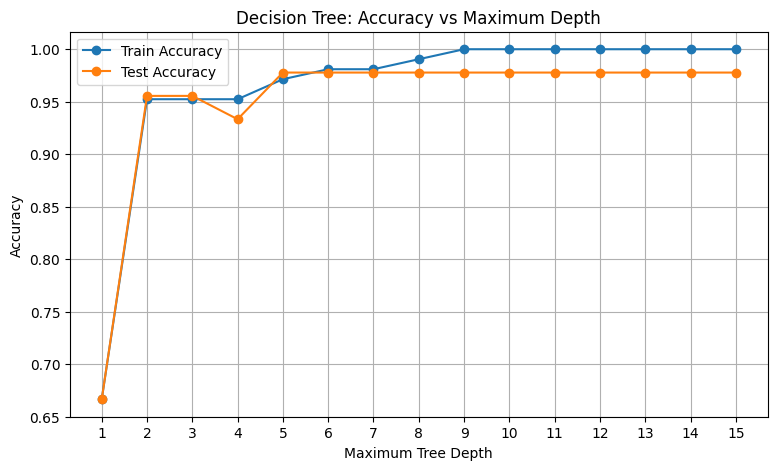

In [9]:
# Write your answer here

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

depths = range(1, 16)
train_accuracies = []
test_accuracies = []
for depth in depths:
    tree = DecisionTreeClassifier(
        criterion='entropy',
        max_depth=depth,
        random_state=1
    )
    tree.fit(X_train, y_train)
    train_pred = tree.predict(X_train)
    test_pred = tree.predict(X_test)
    train_accuracies.append(accuracy_score(y_train, train_pred))
    test_accuracies.append(accuracy_score(y_test, test_pred))
print("Depth | Train Accuracy | Test Accuracy")
for i, depth in enumerate(depths):
    print(f"{depth:5} | {train_accuracies[i]:14.4f} | {test_accuracies[i]:13.4f}")
best_index = test_accuracies.index(max(test_accuracies))
print("\nBest depth:", list(depths)[best_index])
print("Best test accuracy:", round(test_accuracies[best_index], 4))
plt.figure(figsize=(9, 5))
plt.plot(depths, train_accuracies, marker='o', label='Train Accuracy')
plt.plot(depths, test_accuracies, marker='o', label='Test Accuracy')
plt.xlabel('Maximum Tree Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree: Accuracy vs Maximum Depth')
plt.xticks(list(depths))
plt.legend()
plt.grid(True)
plt.show()

**Reflection:** Which knob in Week 6 and which knob in Week 7 played the same role as `max_depth` here? What happens at each extreme?

*Your answer:* In week 6 polynomial degree. A low degree may underfit, while a high degree may overfit. In week 7 KNN k value. A small k may overfit, while a large k may underfit. In decision tree max_depth. A shallow tree may underfit, while a deep tree may overfit.


# Mini Project A: Digits, Again (Image Track — continuing from Week 7)

Last week KNN reached about 98% on the digits dataset. Now fit a decision tree on the **same split** and ask two new questions: how does it compare, and **which pixels does the tree actually use?**


In [10]:
digits = load_digits()
Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    digits.data, digits.target, test_size=0.3, random_state=1, stratify=digits.target)

# KNN baseline from Week 7 (scaled, K=3)
sc = StandardScaler().fit(Xd_train)
knn = KNeighborsClassifier(n_neighbors=3).fit(sc.transform(Xd_train), yd_train)
print('KNN  test accuracy:', accuracy_score(yd_test, knn.predict(sc.transform(Xd_test))))

KNN  test accuracy: 0.9796296296296296


### Student Practice

1. Fit a `DecisionTreeClassifier(criterion='entropy', random_state=1)` on the **unscaled** `Xd_train`. Print test accuracy. (Why is no scaling needed?)
2. Try `max_depth` values 3, 6, 10 and report test accuracy for each.
3. Take `tree.feature_importances_` (64 values), reshape to 8×8 and show it with `plt.imshow`. Which region of the image does the tree rely on?


KNN test accuracy: 0.9796296296296296
Decision Tree test accuracy: 0.8814814814814815

Accuracy for different depths:
Depth 3: 0.5296
Depth 6: 0.8537
Depth 10: 0.8796


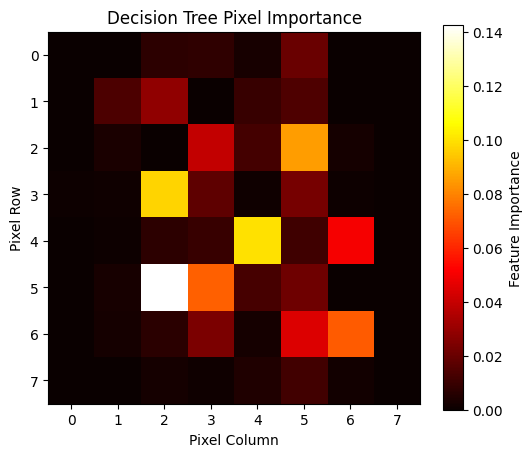


Most important pixel:
Row: 5 Column: 2
Importance: 0.1426


In [11]:
# Write your answer here

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
tree = DecisionTreeClassifier(
    criterion='entropy',
    random_state=1
)
tree.fit(Xd_train, yd_train)
tree_pred = tree.predict(Xd_test)
print("KNN test accuracy:",
      accuracy_score(yd_test, knn.predict(sc.transform(Xd_test))))
print("Decision Tree test accuracy:",
      accuracy_score(yd_test, tree_pred))
print("\nAccuracy for different depths:")
for depth in [3, 6, 10]:
    model = DecisionTreeClassifier(
        criterion='entropy',
        max_depth=depth,
        random_state=1
    )
    model.fit(Xd_train, yd_train)
    pred = model.predict(Xd_test)
    print(f"Depth {depth}: {accuracy_score(yd_test, pred):.4f}")
importance = tree.feature_importances_
importance_image = importance.reshape(8, 8)
plt.figure(figsize=(6, 5))
plt.imshow(importance_image, cmap='hot', interpolation='nearest')
plt.colorbar(label='Feature Importance')
plt.title('Decision Tree Pixel Importance')
plt.xlabel('Pixel Column')
plt.ylabel('Pixel Row')
plt.xticks(range(8))
plt.yticks(range(8))
plt.show()
index = np.argmax(importance)
row, col = divmod(index, 8)
print("\nMost important pixel:")
print("Row:", row, "Column:", col)
print("Importance:", round(importance[index], 4))

**Reflection:** Is the tree more or less accurate than KNN on digits? Offer one reason, using what the importance map shows you.

*Your answer:* The Decision Tree is less accurate than KNN on digits. The importance map shows that the tree focuses on certain pixels, so it may miss other important patterns needed to recognize digits correctly.


# Mini Project B: Reading a Tree on Text (NLP Track — continuing from Week 7)

Same six labeled sentences and same bag-of-words vectors as Week 7. A tree gives you something KNN cannot: **the words it chose to split on.**


In [13]:
sentences = [
    'the cricket team won the match',
    'the batsman scored a century today',
    'chop the onions and boil the pasta',
    'add salt and simmer the curry',
    'the new phone has a faster processor',
    'the laptop battery lasts all day',
]
labels = ['sports', 'sports', 'cooking', 'cooking', 'tech', 'tech']

vocab = sorted(set(w for s in sentences for w in s.lower().split()))

def to_vector(sentence, vocab):
    words = sentence.lower().split()
    return np.array([words.count(w) for w in vocab])

X_text = np.array([to_vector(s, vocab) for s in sentences])


### Student Practice

1. Fit a `DecisionTreeClassifier(criterion='entropy', random_state=1)` on `X_text`, `labels`.
2. Print the tree with `export_text(tree, feature_names=vocab)`. Which words does it split on?
3. Predict the topic of `'the striker scored a goal'` and of your own ambiguous sentence from Week 7.


In [14]:
# Write your answer here

from sklearn.tree import DecisionTreeClassifier, export_text
tree = DecisionTreeClassifier(
    criterion='entropy',
    random_state=1
)
tree.fit(X_text, labels)
print(export_text(tree, feature_names=vocab))
sentence1 = 'the striker scored a goal'
sentence2 = 'the phone team won the game'
X_new = np.array([
    to_vector(sentence1, vocab),
    to_vector(sentence2, vocab)
])
predictions = tree.predict(X_new)
print("Sentence:", sentence1, "-> Topic:", predictions[0])
print("Sentence:", sentence2, "-> Topic:", predictions[1])

|--- and <= 0.50
|   |--- has <= 0.50
|   |   |--- laptop <= 0.50
|   |   |   |--- class: sports
|   |   |--- laptop >  0.50
|   |   |   |--- class: tech
|   |--- has >  0.50
|   |   |--- class: tech
|--- and >  0.50
|   |--- class: cooking

Sentence: the striker scored a goal -> Topic: sports
Sentence: the phone team won the game -> Topic: sports


**Reflection:** If you added 3 more sentences per topic, would you expect the same split words? What does that tell you about trusting a tree trained on very little data?

*Your answer:* No,we cannot expectv the same split after addiung the data.training the tree on less datd leads to overfit so we have to trin with more data.


## Summary

| What we did | Why it matters |
|---|---|
| Entropy and information gain | The rule ID3 uses to choose every split |
| ID3 by hand on the tennis table | Exam-style problem, show your working |
| `DecisionTreeClassifier` and depth sweep | Third version of the bias-variance knob (degree, K, depth) |
| Mini A: digits | Tree vs KNN on the same data, plus which pixels matter |
| Mini B: text | A tree you can read, and why tiny data makes it fragile |

**Next week:** Naive Bayes, a probabilistic classifier. Same digits and sentences again.
